Evaluate Random Agent

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/MECE689_Bowling/MECE689_RL_Bowling_Atari
!ls -la

/content/drive/MyDrive/MECE689_Bowling/MECE689_RL_Bowling_Atari
total 41
drwx------ 2 root root  4096 Sep 25 15:17 code
drwx------ 2 root root  4096 Sep 25 15:04 .git
-rw------- 1 root root 13586 Oct 31 06:01 github_terminal.ipynb
-rw------- 1 root root    33 Sep 26 19:25 .gitignore
drwx------ 2 root root  4096 Sep 25 15:17 models
drwx------ 2 root root  4096 Oct 31 02:25 OLD
-rw------- 1 root root  2348 Sep 29 02:21 README.md
drwx------ 2 root root  4096 Sep 25 15:17 results
drwx------ 2 root root  4096 Oct 18 05:10 videos


In [3]:
!pip install stable-baselines3 gymnasium[atari,accept-rom-license] ale-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 4.8 MB/s eta 0:00:00


In [11]:
from stable_baselines3.common.evaluation import evaluate_policy

import os
import torch
import gymnasium as gym
import stable_baselines3
import ale_py
import numpy as np
import random
import matplotlib.pyplot as plt

# For debugging
from stable_baselines3.common.monitor import Monitor
import time

# Action masking
from gymnasium import ActionWrapper
from stable_baselines3.common.atari_wrappers import AtariWrapper

# Vector environment
from stable_baselines3.common.vec_env import VecFrameStack, DummyVecEnv

print("All imports working")

All imports working


In [ ]:
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
def convert(seconds):
    seconds = seconds % (24 * 3600)
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60

    return "%d:%02d:%02d" % (hour, minutes, seconds)

Create Environment

In [ ]:
class ActionReducer(ActionWrapper):
  def __init__(self, env):
    super().__init__(env)

    # NOOP, FIRE, UP, and DOWN only. No UPFIRE. No DOWNFIRE.
    self.allowed_actions = [0,1,2,3]

    self.action_space = gym.spaces.Discrete(len(self.allowed_actions))

  def action(self, action):
    return self.allowed_actions[action]

In [ ]:
seed = 23
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
def make_env():
  # DQN only supports single environments (not vectorized)
  env = gym.make("ALE/Bowling-v5")

  # disable reward clipping
  env = AtariWrapper(env, clip_reward=False)

  env = ActionReducer(env)
  # Monitor should wrap it last. Gives the Mean Episode Length & Reward
  env = Monitor(env)

  env.reset(seed=seed)
  env.action_space.seed(seed)
  return env

In [ ]:
env = DummyVecEnv([make_env])
env = VecFrameStack(env, n_stack=4)

Random Agent

In [ ]:
all_random_rewards = []
all_random_lengths = []

total_episodes = 10000   # 10K
# total_episodes = 10      # for simple tests

print("Running evaluation of random agent")
start_time = time.time()

for episode in range(total_episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    steps = 0

    while not done:
      # agent picks a random action
      # Gym env might use np.random for sampling actions, or Python's random... but both ARE set above, so it should be reproducible...
      action = env.action_space.sample()
      # The action needs to be a list for the vectorized environment
      obs, reward, done, info = env.step([action])
      total_reward += reward[0]
      steps += 1

    all_random_rewards.append(total_reward)
    all_random_lengths.append(steps)
    # print(f"Episode {episode+1}: Reward = {total_reward:6.1f}, Steps = {steps}")

end_time = time.time()

# Calculate run time
training_duration = end_time - start_time
time_in_minutes_and_seconds = convert(training_duration)
print(f"Time taken: {time_in_minutes_and_seconds}")

Running evaluation of random agent
Time taken: 4:00:41


In [ ]:
env.close()

SAVE episodes, reward, and steps to its own file

In [ ]:
random_agent_results_folder = "/content/drive/MyDrive/MECE689_Bowling/MECE689_RL_Bowling_Atari/results"

all_random_rewards_path = f"{random_agent_results_folder}/all_random_rewards.npy"
all_random_lengths_path = f"{random_agent_results_folder}/all_random_lengths.npy"

In [ ]:
# Save to .npy files
np.save(all_random_rewards_path, np.array(all_random_rewards))
np.save(all_random_lengths_path, np.array(all_random_lengths))

print("Saved random agent results to files!")

Saved random agent results to files!


LOAD random agent eval results

In [ ]:
# Load from .npy files
random_rewards_array = np.load(all_random_rewards_path)
random_lengths_array = np.load(all_random_lengths_path)

print("Loaded saved random agent results!")

Loaded saved random agent results!


Evaluate Performance

In [ ]:
# Calculate metrics
# random_rewards_array = np.array(all_random_rewards)
# random_lengths_array = np.array(all_random_lengths)

print("Evaluation metrics of RANDOM AGENT:")
print(f"Total episodes: {total_episodes}")
print(f"Mean reward: {np.mean(random_rewards_array):.2f}")
print(f"Median reward: {np.median(random_rewards_array):.2f}")
print(f"Min reward: {np.min(random_rewards_array):.2f}")
print(f"Max reward: {np.max(random_rewards_array):.2f}")
print(f"Standard deviation: {np.std(random_rewards_array):.2f}")
print(f"Average episode length: {np.mean(random_lengths_array):.1f} steps")

Evaluation metrics of RANDOM AGENT:
Total episodes: 10000
Mean reward: 27.74
Median reward: 27.00
Min reward: 3.00
Max reward: 71.00
Standard deviation: 9.46
Average episode length: 568.3 steps


In [ ]:
# # RESULTS:
# Evaluation metrics of RANDOM AGENT:
# Total episodes: 10000
# Mean reward: 27.74
# Median reward: 27.00
# Min reward: 3.00
# Max reward: 71.00
# Standard deviation: 9.46
# Average episode length: 568.3 steps

In [5]:
random_agent_results_folder = "/content/drive/MyDrive/MECE689_Bowling/MECE689_RL_Bowling_Atari/results"

all_random_rewards_path = f"{random_agent_results_folder}/all_random_rewards.npy"
all_random_lengths_path = f"{random_agent_results_folder}/all_random_lengths.npy"

In [6]:
# Load from .npy files
random_rewards_array = np.load(all_random_rewards_path)
random_lengths_array = np.load(all_random_lengths_path)

print("Loaded saved random agent results!")

Loaded saved random agent results!


In [19]:
label = 'Random'
arr = random_rewards_array

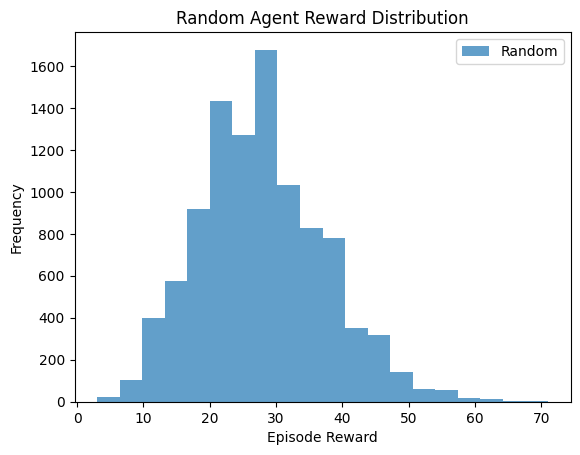

In [20]:
# Histogram
plt.hist(arr, alpha=0.7, label=label, bins=20)
plt.xlabel('Episode Reward')
plt.ylabel('Frequency')
plt.legend()
plt.title(f'{label} Agent Reward Distribution')
plt.show()

/tmp/ipython-input-3972990239.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


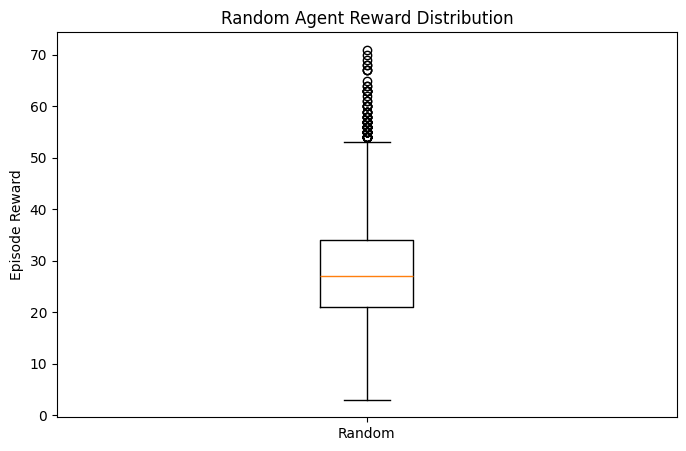

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# Box Plot
plt.figure(figsize=(8, 5))
plt.boxplot([arr], labels=[label])
plt.ylabel('Episode Reward')
plt.title(f'{label} Agent Reward Distribution')
plt.show()